In [97]:
# import os
# os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [78]:
# pip install seaborn

In [42]:
# pip install matplotlib

Load the data

In [2]:
df_power = pd.read_csv('data/power.csv')
df_porduction = pd.read_csv('data/production_log.csv')
df_vibration = pd.read_csv('data/vibration.csv')

In [3]:
df_power.shape, df_porduction.shape, df_vibration.shape

((86405, 3), (94, 7), (168969, 4))

In [4]:
df_power.info()

<class 'pandas.DataFrame'>
RangeIndex: 86405 entries, 0 to 86404
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   86405 non-null  str    
 1   machine_id  86405 non-null  str    
 2   power_kw    86389 non-null  float64
dtypes: float64(1), str(2)
memory usage: 2.0 MB


In [5]:
df_porduction.info()

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   job_id      94 non-null     str    
 1   machine_id  94 non-null     str    
 2   part_type   94 non-null     str    
 3   operator    94 non-null     str    
 4   quantity    91 non-null     float64
 5   start_time  94 non-null     str    
 6   end_time    94 non-null     str    
dtypes: float64(1), str(6)
memory usage: 5.3 KB


In [6]:
df_vibration.info()

<class 'pandas.DataFrame'>
RangeIndex: 168969 entries, 0 to 168968
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   timestamp         168969 non-null  str    
 1   machine_id        168969 non-null  str    
 2   vibration_rms_g   168969 non-null  float64
 3   vibration_peak_g  168969 non-null  float64
dtypes: float64(2), str(2)
memory usage: 5.2 MB


Unify formating

In [7]:
df_power['timestamp'] = pd.to_datetime(df_power['timestamp'])
df_porduction['start_time'] = pd.to_datetime(df_porduction['start_time'])
df_porduction['end_time'] = pd.to_datetime(df_porduction['end_time'])
df_vibration['timestamp'] = pd.to_datetime(df_vibration['timestamp'])
df_porduction['start_time'] = df_porduction['start_time'].dt.tz_localize('UTC')
df_porduction['end_time'] = df_porduction['end_time'].dt.tz_localize('UTC')

In [8]:
df_power.head()

,timestamp,machine_id,power_kw
0,2025-03-10 13:00:00+00:00,CNC-07,0.598
1,2025-03-10 13:00:01+00:00,CNC-07,0.592
2,2025-03-10 13:00:02+00:00,CNC-07,0.739
3,2025-03-10 13:00:03+00:00,CNC-07,0.566
4,2025-03-10 13:00:04+00:00,CNC-07,0.639


In [9]:
df_power.timestamp.min(), df_power.timestamp.max()

(Timestamp('2025-03-10 13:00:00+0000', tz='UTC'),
 Timestamp('2025-03-10 20:59:59+0000', tz='UTC'))

In [10]:
df_porduction.head()

,job_id,machine_id,part_type,operator,quantity,start_time,end_time
0,JOB-001,CNC-07,AL-bracket,L. Petrova,4.0,2025-03-10 08:03:40+00:00,2025-03-10 08:07:11+00:00
1,JOB-002,CNC-07,AL-bracket,A. Nguyen,7.0,2025-03-10 08:09:36+00:00,2025-03-10 08:18:32+00:00
2,JOB-003,CNC-07,AL-panel,M. Reyes,10.0,2025-03-10 08:20:24+00:00,2025-03-10 08:28:21+00:00
3,JOB-004,CNC-07,AL-panel,M. Reyes,1.0,2025-03-10 08:29:31+00:00,2025-03-10 08:32:48+00:00
4,JOB-005,CNC-07,TI-fitting,M. Reyes,12.0,2025-03-10 08:34:19+00:00,2025-03-10 08:42:45+00:00


In [11]:
df_vibration.head()

,timestamp,machine_id,vibration_rms_g,vibration_peak_g
0,2025-03-10 13:00:12+00:00,CNC-07,0.0597,0.1749
1,2025-03-10 13:00:12.500000+00:00,CNC-07,0.0405,0.1198
2,2025-03-10 13:00:13+00:00,CNC-07,0.0382,0.0933
3,2025-03-10 13:00:13.501000+00:00,CNC-07,0.0671,0.1890
4,2025-03-10 13:00:14.001000+00:00,CNC-07,0.0456,0.1350


Merging dataframes

In [12]:
df_power_and_production = df_power.merge(df_porduction, on = ['machine_id'])

In [13]:
df_power_and_production.info()

<class 'pandas.DataFrame'>
RangeIndex: 2707386 entries, 0 to 2707385
Data columns (total 9 columns):
 #   Column      Dtype              
---  ------      -----              
 0   timestamp   datetime64[us, UTC]
 1   machine_id  str                
 2   power_kw    float64            
 3   job_id      str                
 4   part_type   str                
 5   operator    str                
 6   quantity    float64            
 7   start_time  datetime64[us, UTC]
 8   end_time    datetime64[us, UTC]
dtypes: datetime64[us, UTC](3), float64(2), str(4)
memory usage: 185.9 MB


Filter out only this rowns with consistent production time and power log time.

In [18]:
df_power_and_production_filtered = df_power_and_production[(df_power_and_production['timestamp']>=df_power_and_production['start_time']) & (df_power_and_production['timestamp']<=df_power_and_production['end_time'])]

In [15]:
df_vibration

,timestamp,machine_id,vibration_rms_g,vibration_peak_g
0,2025-03-10 13:00:12+00:00,CNC-07,0.0597,0.1749
1,2025-03-10 13:00:12.500000+00:00,CNC-07,0.0405,0.1198
2,2025-03-10 13:00:13+00:00,CNC-07,0.0382,0.0933
3,2025-03-10 13:00:13.501000+00:00,CNC-07,0.0671,0.1890
4,2025-03-10 13:00:14.001000+00:00,CNC-07,0.0456,0.1350
...,...,...,...,...
168964,2025-03-10 21:00:53.058000+00:00,CNC-11,0.0416,0.1294
168965,2025-03-10 21:00:53.558000+00:00,CNC-11,0.0515,0.1589
168966,2025-03-10 21:00:54.059000+00:00,CNC-11,0.0269,0.0820
168967,2025-03-10 13:05:10.848000+00:00,CNC-11,0.5050,1.5859


In [17]:
df_power_and_production

,timestamp,machine_id,power_kw,job_id,part_type,operator,quantity,start_time,end_time
0,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-001,AL-bracket,L. Petrova,4.0,2025-03-10 08:03:40+00:00,2025-03-10 08:07:11+00:00
1,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-002,AL-bracket,A. Nguyen,7.0,2025-03-10 08:09:36+00:00,2025-03-10 08:18:32+00:00
2,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-003,AL-panel,M. Reyes,10.0,2025-03-10 08:20:24+00:00,2025-03-10 08:28:21+00:00
3,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-004,AL-panel,M. Reyes,1.0,2025-03-10 08:29:31+00:00,2025-03-10 08:32:48+00:00
4,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-005,TI-fitting,M. Reyes,12.0,2025-03-10 08:34:19+00:00,2025-03-10 08:42:45+00:00
...,...,...,...,...,...,...,...,...,...
2707381,2025-03-10 17:49:24+00:00,CNC-11,0.561,JOB-220,ST-housing,L. Petrova,14.0,2025-03-10 11:19:00+00:00,2025-03-10 11:07:00+00:00
2707382,2025-03-10 17:49:24+00:00,CNC-11,0.561,JOB-221,ST-housing,S. Tanaka,7.0,2025-03-10 11:20:00+00:00,2025-03-10 11:23:00+00:00
2707383,2025-03-10 17:49:24+00:00,CNC-11,0.561,JOB-222,AL-bracket,M. Okafor,20.0,2025-03-10 11:27:00+00:00,2025-03-10 11:36:00+00:00
2707384,2025-03-10 17:49:24+00:00,CNC-11,0.561,JOB-223,TI-fitting,S. Tanaka,6.0,2025-03-10 11:40:00+00:00,2025-03-10 11:50:00+00:00


In [21]:
df_power_and_production_and_vibration = df_power_and_production_filtered.merge(df_vibration, on = ['machine_id'], suffixes=('_power', '_vibration'))

In [23]:
df_power_and_production_and_vibration_filtered = df_power_and_production_and_vibration[(df_power_and_production_and_vibration['timestamp_vibration']>=df_power_and_production_and_vibration['start_time']) & (df_power_and_production_and_vibration['timestamp_vibration']<=df_power_and_production_and_vibration['end_time'])]

In [24]:
df_power_and_production_and_vibration_filtered

,timestamp_power,machine_id,power_kw,job_id,part_type,operator,quantity,start_time,end_time,timestamp_vibration,vibration_rms_g,vibration_peak_g
0,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-040,ST-housing,J. Okafor,5.0,2025-03-10 12:52:24+00:00,2025-03-10 13:00:40+00:00,2025-03-10 13:00:12+00:00,0.0597,0.1749
1,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-040,ST-housing,J. Okafor,5.0,2025-03-10 12:52:24+00:00,2025-03-10 13:00:40+00:00,2025-03-10 13:00:12.500000+00:00,0.0405,0.1198
2,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-040,ST-housing,J. Okafor,5.0,2025-03-10 12:52:24+00:00,2025-03-10 13:00:40+00:00,2025-03-10 13:00:13+00:00,0.0382,0.0933
3,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-040,ST-housing,J. Okafor,5.0,2025-03-10 12:52:24+00:00,2025-03-10 13:00:40+00:00,2025-03-10 13:00:13.501000+00:00,0.0671,0.1890
4,2025-03-10 13:00:00+00:00,CNC-07,0.598,JOB-040,ST-housing,J. Okafor,5.0,2025-03-10 12:52:24+00:00,2025-03-10 13:00:40+00:00,2025-03-10 13:00:14.001000+00:00,0.0456,0.1350
...,...,...,...,...,...,...,...,...,...,...,...,...
98152719,2025-03-10 13:00:00+00:00,CNC-09,0.685,JOB-124,AL-bracket,L. Petrova,17.0,2025-03-10 12:56:00+00:00,2025-03-10 13:00:00+00:00,2025-03-10 12:59:57.501000+00:00,0.0383,0.1212
98152720,2025-03-10 13:00:00+00:00,CNC-09,0.685,JOB-124,AL-bracket,L. Petrova,17.0,2025-03-10 12:56:00+00:00,2025-03-10 13:00:00+00:00,2025-03-10 12:59:58.001000+00:00,0.0435,0.1435
98152721,2025-03-10 13:00:00+00:00,CNC-09,0.685,JOB-124,AL-bracket,L. Petrova,17.0,2025-03-10 12:56:00+00:00,2025-03-10 13:00:00+00:00,2025-03-10 12:59:58.501000+00:00,0.0535,0.1601
98152722,2025-03-10 13:00:00+00:00,CNC-09,0.685,JOB-124,AL-bracket,L. Petrova,17.0,2025-03-10 12:56:00+00:00,2025-03-10 13:00:00+00:00,2025-03-10 12:59:59.002000+00:00,0.0370,0.1105


Grouping df by jobs; data are consistent

All the jobs for different parts that need to be checked.

In [25]:
df_power_and_production_and_vibration_filtered[['machine_id','job_id','part_type','start_time','end_time']].value_counts()

machine_id  job_id   part_type   start_time                 end_time                 
CNC-07      JOB-046  ST-gear     2025-03-10 13:33:56+00:00  2025-03-10 13:42:24+00:00    516635
            JOB-042  AL-bracket  2025-03-10 13:08:31+00:00  2025-03-10 13:16:37+00:00    472877
            JOB-041  AL-bracket  2025-03-10 13:01:50+00:00  2025-03-10 13:06:31+00:00    158484
            JOB-044  ST-gear     2025-03-10 13:23:19+00:00  2025-03-10 13:27:19+00:00    115680
            JOB-043  TI-fitting  2025-03-10 13:18:22+00:00  2025-03-10 13:21:59+00:00     94394
            JOB-040  ST-housing  2025-03-10 12:52:24+00:00  2025-03-10 13:00:40+00:00      2296
CNC-09      JOB-124  AL-bracket  2025-03-10 12:56:00+00:00  2025-03-10 13:00:00+00:00        12
Name: count, dtype: int64

In [31]:
list(df_power_and_production_and_vibration_filtered[['machine_id','job_id','part_type','start_time','end_time']].value_counts().index)

[('CNC-07',
  'JOB-046',
  'ST-gear',
  Timestamp('2025-03-10 13:33:56+0000', tz='UTC'),
  Timestamp('2025-03-10 13:42:24+0000', tz='UTC')),
 ('CNC-07',
  'JOB-042',
  'AL-bracket',
  Timestamp('2025-03-10 13:08:31+0000', tz='UTC'),
  Timestamp('2025-03-10 13:16:37+0000', tz='UTC')),
 ('CNC-07',
  'JOB-041',
  'AL-bracket',
  Timestamp('2025-03-10 13:01:50+0000', tz='UTC'),
  Timestamp('2025-03-10 13:06:31+0000', tz='UTC')),
 ('CNC-07',
  'JOB-044',
  'ST-gear',
  Timestamp('2025-03-10 13:23:19+0000', tz='UTC'),
  Timestamp('2025-03-10 13:27:19+0000', tz='UTC')),
 ('CNC-07',
  'JOB-043',
  'TI-fitting',
  Timestamp('2025-03-10 13:18:22+0000', tz='UTC'),
  Timestamp('2025-03-10 13:21:59+0000', tz='UTC')),
 ('CNC-07',
  'JOB-040',
  'ST-housing',
  Timestamp('2025-03-10 12:52:24+0000', tz='UTC'),
  Timestamp('2025-03-10 13:00:40+0000', tz='UTC')),
 ('CNC-09',
  'JOB-124',
  'AL-bracket',
  Timestamp('2025-03-10 12:56:00+0000', tz='UTC'),
  Timestamp('2025-03-10 13:00:00+0000', tz='UTC'))

In [127]:
df_power_and_production_and_vibration_filtered[['machine_id','job_id','part_type','start_time','end_time']].value_counts()

machine_id  job_id   part_type   start_time                 end_time                 
CNC-07      JOB-046  ST-gear     2025-03-10 13:33:56+00:00  2025-03-10 13:42:24+00:00    516635
            JOB-042  AL-bracket  2025-03-10 13:08:31+00:00  2025-03-10 13:16:37+00:00    472877
            JOB-041  AL-bracket  2025-03-10 13:01:50+00:00  2025-03-10 13:06:31+00:00    158484
            JOB-044  ST-gear     2025-03-10 13:23:19+00:00  2025-03-10 13:27:19+00:00    115680
            JOB-043  TI-fitting  2025-03-10 13:18:22+00:00  2025-03-10 13:21:59+00:00     94394
            JOB-040  ST-housing  2025-03-10 12:52:24+00:00  2025-03-10 13:00:40+00:00      2296
CNC-09      JOB-124  AL-bracket  2025-03-10 12:56:00+00:00  2025-03-10 13:00:00+00:00        12
Name: count, dtype: int64

In [26]:
df_power_and_production_and_vibration_filtered[['machine_id','job_id','part_type','start_time','end_time']].value_counts().shape

(7,)

In [34]:
job_configs = list(df_power_and_production_and_vibration_filtered[['machine_id','job_id','part_type','start_time','end_time']].value_counts().index)

In [56]:
def get_the_subset(df: pd.DataFrame, machine_id: str, job_id: str, part_type: str, start_time: str, end_time: str) -> pd.DataFrame:
    """
    Get the subset of the dataframe based on the given parameters.

    Args:
        df (pd.DataFrame): The dataframe to filter.
        machine_id (str): The machine ID to filter by.
        job_id (str): The job ID to filter by.
        part_type (str): The part type to filter by.
        start_time (str): The start time to filter by.
        end_time (str): The end time to filter by.

    Returns:
        pd.DataFrame: The filtered dataframe.
    """
    return df[(df['machine_id'] == machine_id) & 
              (df['job_id'] == job_id) & 
              (df['part_type'] == part_type) & 
              (df['start_time'] == start_time) & 
              (df['end_time'] == end_time)].sort_values(by='timestamp_vibration').reset_index(drop=True)


Analysis closer what was in the data by job

Job 0

In [100]:
machine_id = job_configs[0][0]
job_id = job_configs[0][1]
part_type = job_configs[0][2]
start_time = job_configs[0][3]
end_time = job_configs[0][4]

df_job_0 = get_the_subset(df_power_and_production_and_vibration_filtered, machine_id, job_id, part_type, start_time, end_time)

Looking for dependencies between power_kw and vobration asa well as outliers.

In [101]:
df_job_0

,timestamp_power,machine_id,power_kw,job_id,part_type,operator,quantity,start_time,end_time,timestamp_vibration,vibration_rms_g,vibration_peak_g
0,2025-03-10 13:33:56+00:00,CNC-07,0.556,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:33:56.118000+00:00,0.0599,0.1516
1,2025-03-10 13:36:24+00:00,CNC-07,15.083,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:33:56.118000+00:00,0.0599,0.1516
2,2025-03-10 13:37:50+00:00,CNC-07,15.736,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:33:56.118000+00:00,0.0599,0.1516
3,2025-03-10 13:38:31+00:00,CNC-07,15.528,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:33:56.118000+00:00,0.0599,0.1516
4,2025-03-10 13:35:42+00:00,CNC-07,14.955,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:33:56.118000+00:00,0.0599,0.1516
...,...,...,...,...,...,...,...,...,...,...,...,...
516630,2025-03-10 13:37:49+00:00,CNC-07,14.274,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:42:23.523000+00:00,0.5795,1.9315
516631,2025-03-10 13:38:30+00:00,CNC-07,15.164,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:42:23.523000+00:00,0.5795,1.9315
516632,2025-03-10 13:39:56+00:00,CNC-07,15.798,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:42:23.523000+00:00,0.5795,1.9315
516633,2025-03-10 13:34:17+00:00,CNC-07,0.467,JOB-046,ST-gear,J. Okafor,9.0,2025-03-10 13:33:56+00:00,2025-03-10 13:42:24+00:00,2025-03-10 13:42:23.523000+00:00,0.5795,1.9315


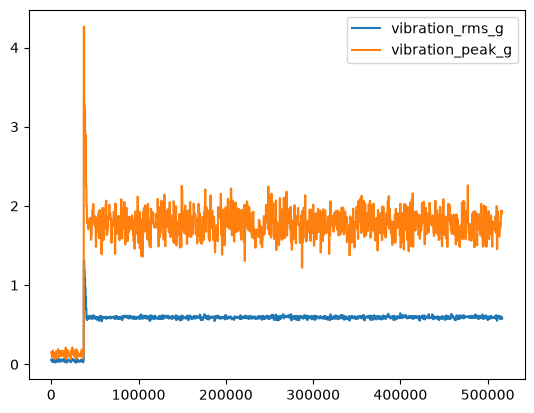

In [102]:
# plt.plot(df_job_0['power_kw'])
plt.plot(df_job_0['vibration_rms_g'], label = 'vibration_rms_g')
plt.plot(df_job_0['vibration_peak_g'], label = 'vibration_peak_g')
plt.legend()


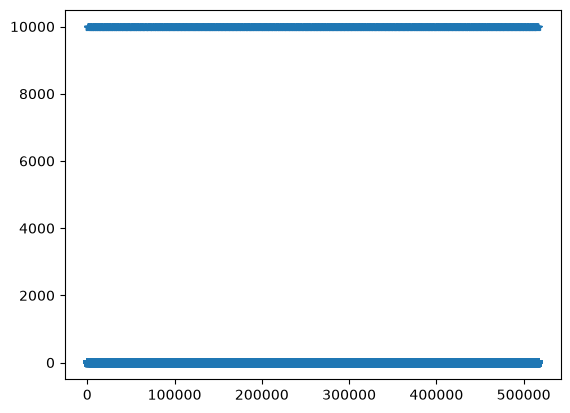

In [103]:
plt.plot(df_job_0['power_kw'],'*')


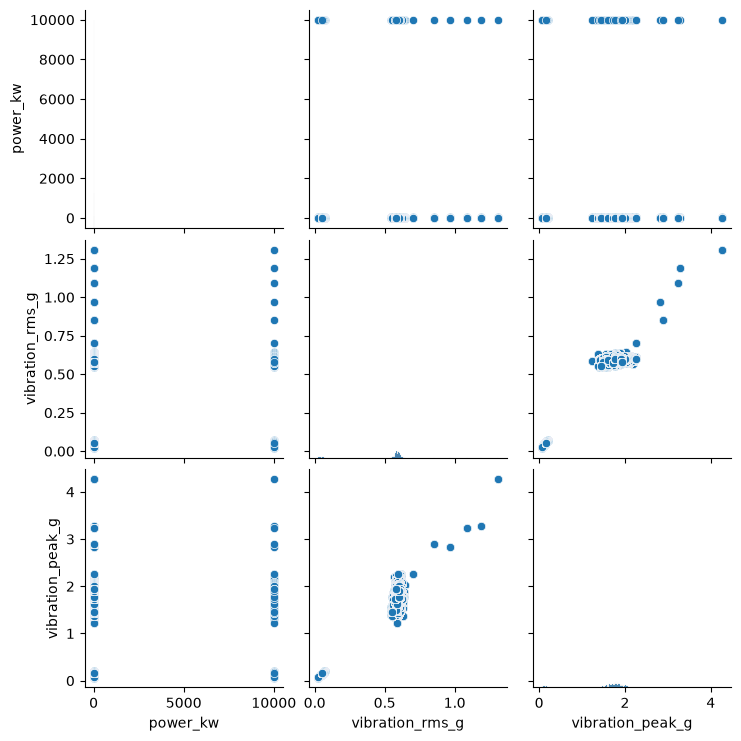

In [104]:
sns.pairplot(df_job_0[['power_kw','vibration_rms_g','vibration_peak_g']])

Those are outliers

In [115]:
df_job_0['power_kw'].nlargest(100)

374      9999.0
857      9999.0
1382     9999.0
1573     9999.0
2329     9999.0
          ...  
48359    9999.0
49339    9999.0
49670    9999.0
50220    9999.0
50806    9999.0
Name: power_kw, Length: 100, dtype: float64

In [116]:
df_job_0[df_job_0['power_kw']<9999]['power_kw'].nlargest(100)

23       25.864
957      25.864
1161     25.864
1916     25.864
2165     25.864
          ...  
48729    25.864
48876    25.864
49872    25.864
50119    25.864
50723    25.864
Name: power_kw, Length: 100, dtype: float64

In [117]:
# df_job_0 = df_job_0[df_job_0['power_kw']<9999]

Job 1

In [68]:
i = 1
machine_id = job_configs[i][0]
job_id = job_configs[i][1]
part_type = job_configs[i][2]
start_time = job_configs[i][3]
end_time = job_configs[i][4]

df_job_1 = get_the_subset(df_power_and_production_and_vibration_filtered, machine_id, job_id, part_type, start_time, end_time)

Looking for dependencies between power_kw and vibration asa well as outliers.

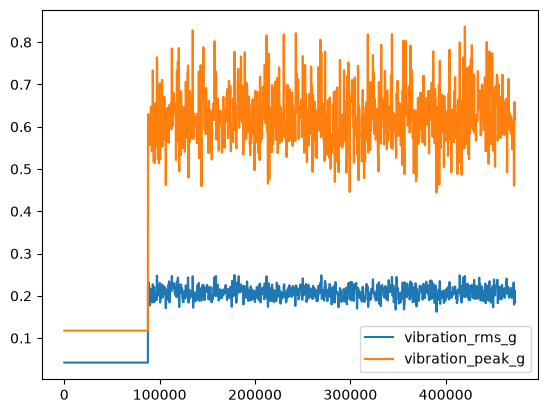

In [70]:
# plt.plot(df_job_0['power_kw'])
plt.plot(df_job_1['vibration_rms_g'], label = 'vibration_rms_g')
plt.plot(df_job_1['vibration_peak_g'], label = 'vibration_peak_g')
plt.legend()


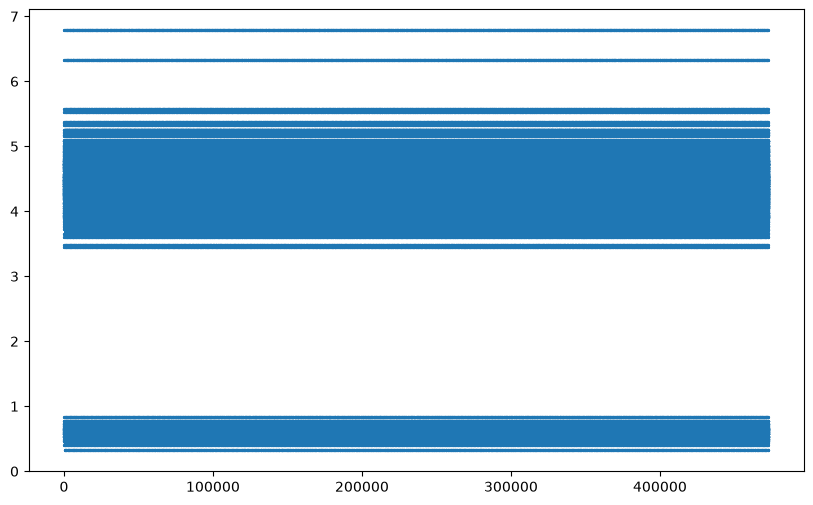

In [76]:
plt.figure(figsize = (10,6))
plt.plot(df_job_1['power_kw'],'*', markersize = 2)


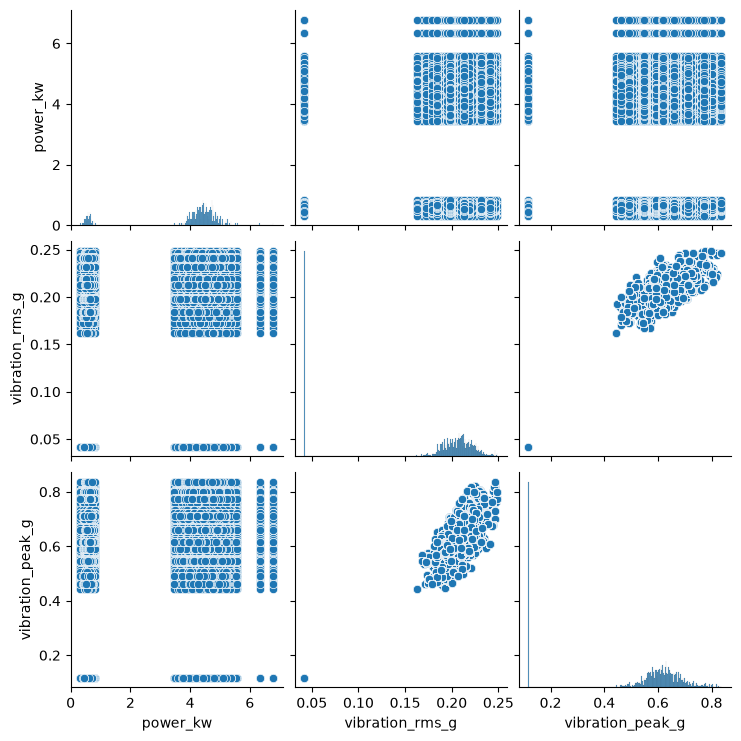

In [80]:
sns.pairplot(df_job_1[['power_kw','vibration_rms_g','vibration_peak_g']])

Trying to identify patterns for good and bad cutting tools

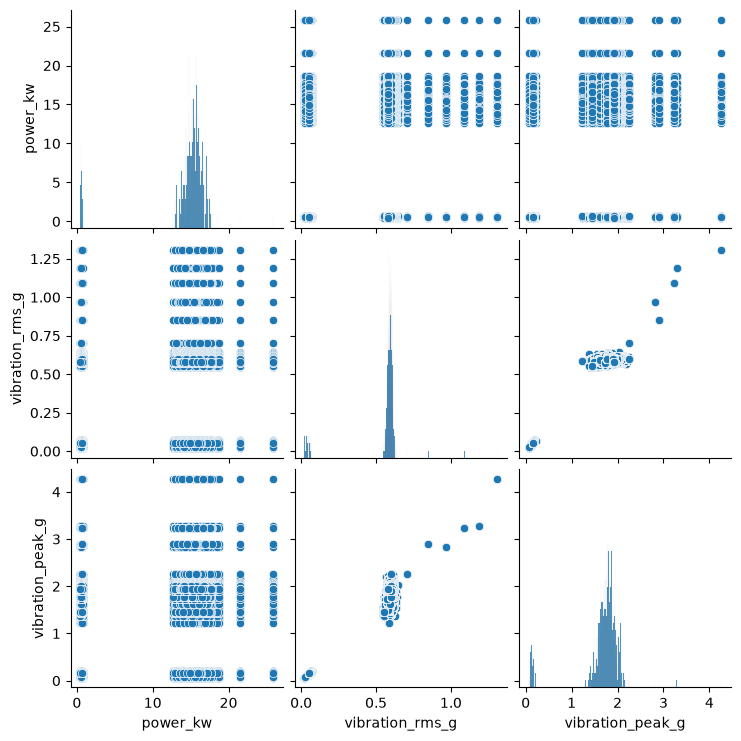

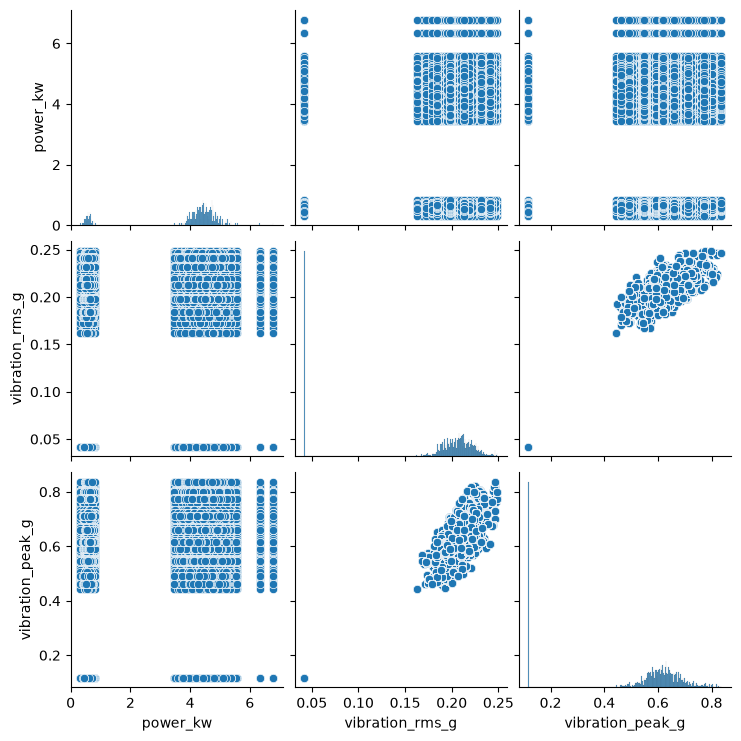

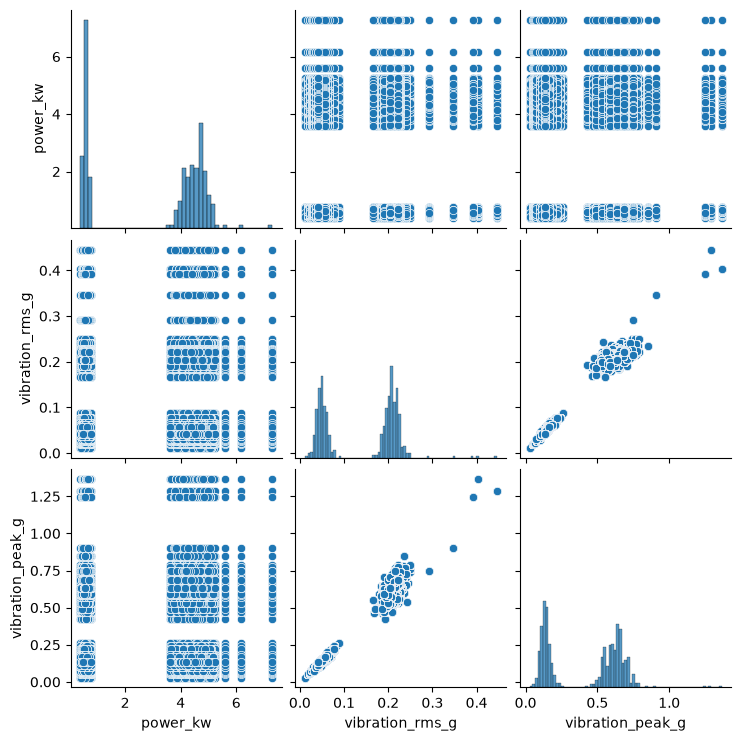

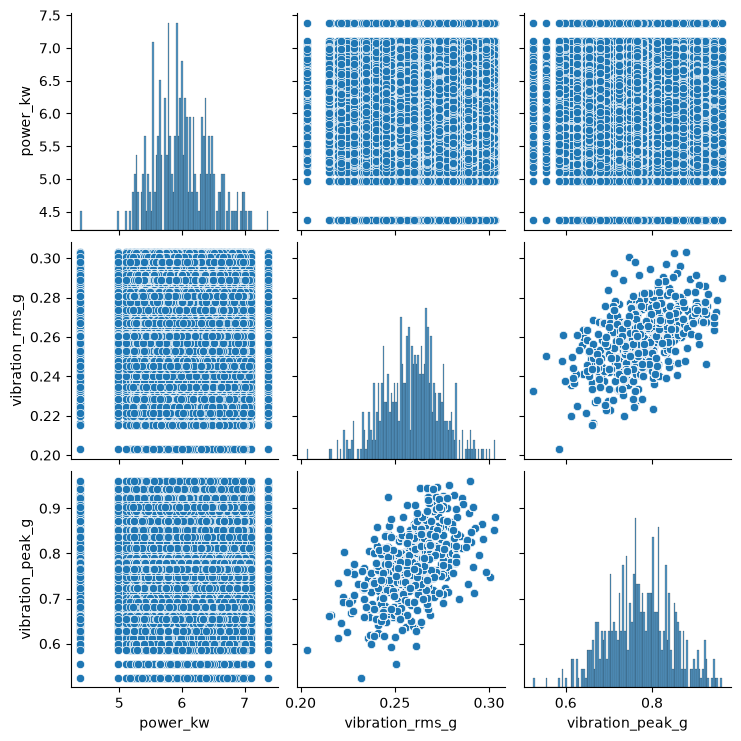

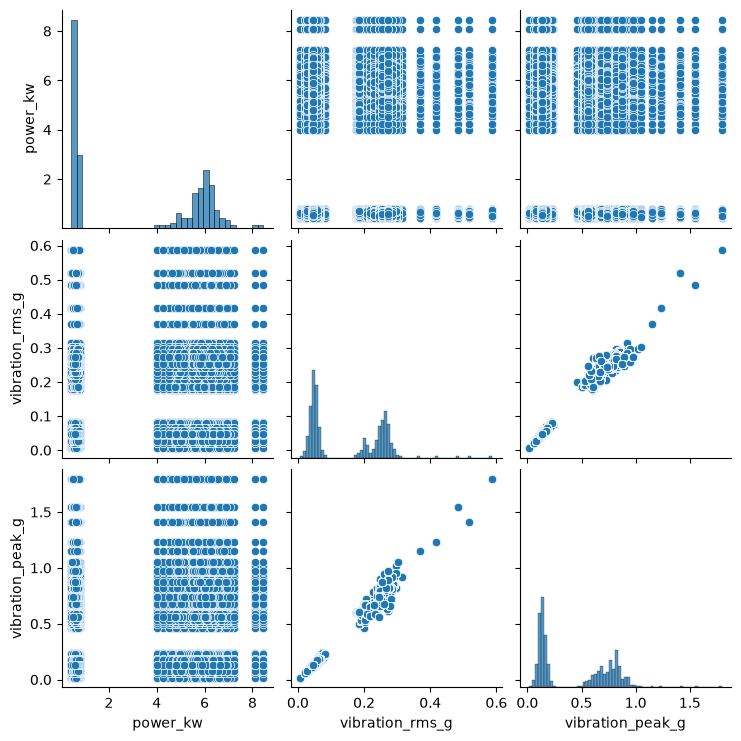

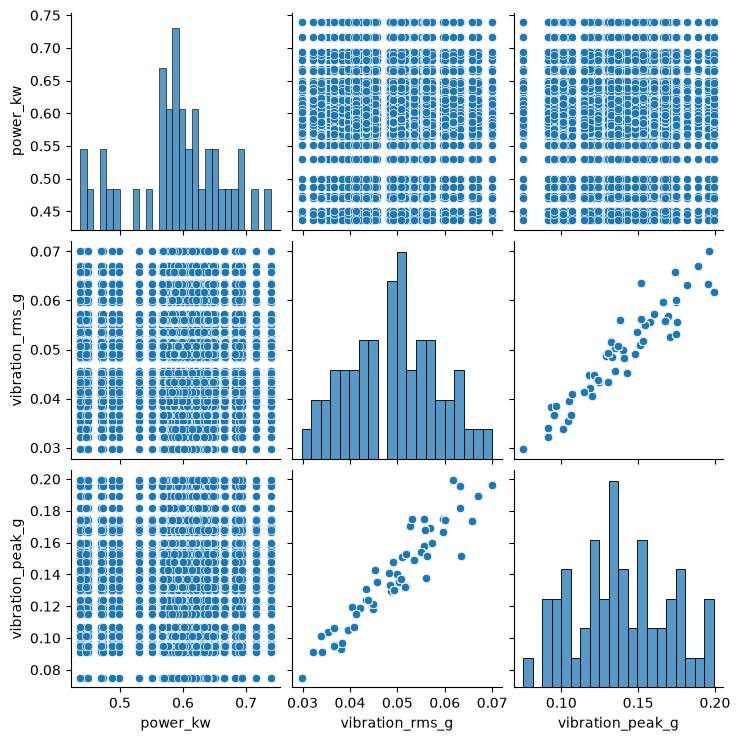

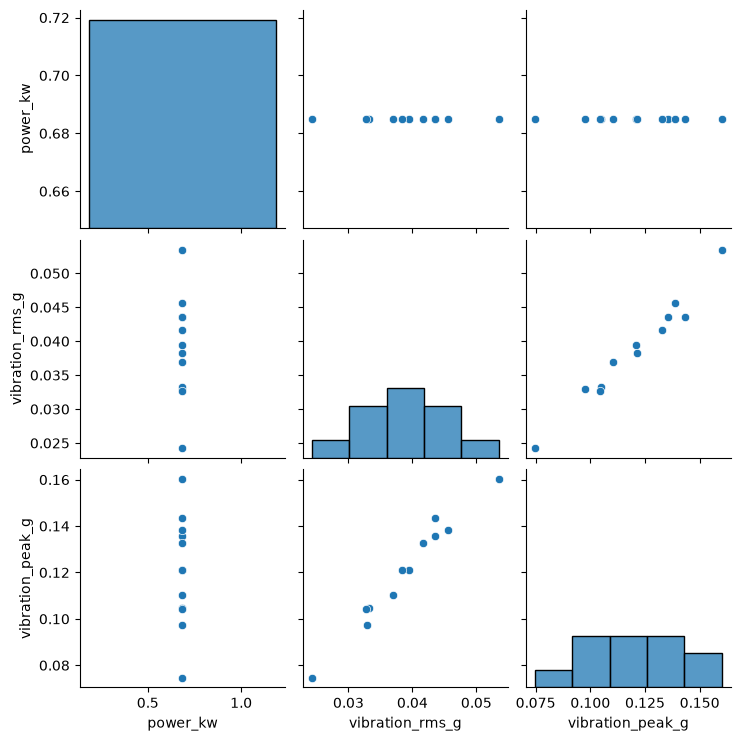

In [118]:
for i in range(len(job_configs)):
    machine_id = job_configs[i][0]
    job_id = job_configs[i][1]
    part_type = job_configs[i][2]
    start_time = job_configs[i][3]
    end_time = job_configs[i][4]

    df_job = get_the_subset(df_power_and_production_and_vibration_filtered, machine_id, job_id, part_type, start_time, end_time)
    df_job = df_job[df_job['power_kw']<9999]

    sns.pairplot(df_job[['power_kw','vibration_rms_g','vibration_peak_g']])

Calculate outliers

In [140]:
for i in range(len(job_configs)):
    machine_id = job_configs[i][0]
    job_id = job_configs[i][1]
    part_type = job_configs[i][2]
    start_time = job_configs[i][3]
    end_time = job_configs[i][4]

    df_job = get_the_subset(df_power_and_production_and_vibration_filtered, machine_id, job_id, part_type, start_time, end_time)
    df_job = df_job[df_job['power_kw']<9999]    

    # 1. Calculate quantails Q1 (25%) i Q3 (75%)
    Q1 = df_job['power_kw'].quantile(0.25)
    Q3 = df_job['power_kw'].quantile(0.75)

    # 2. Calcluate  (IQR)
    IQR = Q3 - Q1

    # 3. Set boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 4.We want to detect too high power consumption
    outliers = df_job[
        (df_job['power_kw'] > upper_bound)
    ]
    print(f'new job {job_id}')
    print(outliers.shape[0]/df_job.shape[0])


new job JOB-046
0.007874015748031496
new job JOB-042
0.006160164271047228
new job JOB-041
0.0
new job JOB-044
0.004149377593360996
new job JOB-043
0.0
new job JOB-040
0.0
new job JOB-124
0.0


Check correlation between vibrations

In [123]:
df_job_0[['vibration_rms_g','vibration_peak_g']].corr().iloc[1,0]

np.float64(0.9494565721108355)

In [125]:
for i in range(len(job_configs)):
    machine_id = job_configs[i][0]
    job_id = job_configs[i][1]
    part_type = job_configs[i][2]
    start_time = job_configs[i][3]
    end_time = job_configs[i][4]

    df_job = get_the_subset(df_power_and_production_and_vibration_filtered, machine_id, job_id, part_type, start_time, end_time)
    df_job = df_job[df_job['power_kw']<9999]    

    corr = np.round(df_job[['vibration_rms_g','vibration_peak_g']].corr().iloc[1,0], 3)
    print(f'new job {job_id}')
    print(corr)


new job JOB-046
0.949
new job JOB-042
0.975
new job JOB-041
0.986
new job JOB-044
0.494
new job JOB-043
0.99
new job JOB-040
0.941
new job JOB-124
0.984


In [142]:
df_job_0.columns 

Index(['timestamp_power', 'machine_id', 'power_kw', 'job_id', 'part_type',
       'operator', 'quantity', 'start_time', 'end_time', 'timestamp_vibration',
       'vibration_rms_g', 'vibration_peak_g'],
      dtype='str')

In [141]:
np.max(df_job_0['vibration_peak_g'])

np.float64(4.264)

Potenetial indicators of dull tools:

-> the most wierdly looking data are those for the first sample, where power usage goes to around 10MW -> were filterout finally. 

What I have noticed: 

-> outliers in power consumption

-> power usage vs. vibration correaltion plot is similar to unifiform distribution showning no dependencies

-> vibration histogram looks like two distributions which could potentialy be two modes of working tools: healthy and dull, or can be a part of the process characteristic

-> circle groups of dots in vibration_rms vs. vibration_peak correlation plots showing that something untypical is happenig there but this can also be due to the process